# H4: Hafta Sonu Etkisi — Cuma Günleri Pazartesi Günlerinden Daha Mı İyi?
## S&P 500 — Kantitatif Araştırma Serisi

**Yazar:** Furkan Çelik  
**Veri:** Özel PostgreSQL pipeline · yfinance API · ~500 hisse · Tüm geçmiş  
**Araçlar:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hipotez Tanımı

| | |
|---|---|
| **Araştırma Sorusu** | Tüm S&P 500 evreni genelinde Cuma ve Pazartesi günlük logaritmik getirileri arasında istatistiksel olarak anlamlı bir fark var mıdır? |
| **H₀ (Sıfır Hipotezi)** | Cuma günlerindeki ortalama günlük logaritmik getiri Pazartesi günleri ile eşittir. |
| **H₁ (Alternatif Hipotez)** | Cuma günlük logaritmik getirileri Pazartesi getirilerinden anlamlı ölçüde **daha yüksektir**. |

### 2. Veri & Metodoloji

| | |
|---|---|
| **Evren (Population)** | S&P 500 bileşenleri · Mevcut tüm geçmiş veriler |
| **Değişkenler** | Günlük logaritmik getiriler: ln(Pₜ / Pₜ₋₁) × 100, SQL LAG() fonksiyonu ile hesaplanmıştır |
| **İstatistiksel Test** | Welch'in Bağımsız İki Örneklem T-Testi (tek kuyruklu) + KDE Dağılım karşılaştırması |
| **Ek Metrikler** | Her iki grup için Çarpıklık (Skewness), Aşırı Basıklık (Fisher Kurtosis) |
| **Anlamlılık Düzeyi** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
from db_utils import fetch_data

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.figsize': (13, 6), 'figure.dpi': 120})
print("Ortam hazır.")


Ortam hazır.


### 3. Veri Çekme

In [2]:
query = """
WITH DailyReturns AS (
    SELECT
        ticker,
        date,
        EXTRACT(ISODOW FROM date) AS day_of_week,
        LN(close / LAG(close) OVER (PARTITION BY ticker ORDER BY date)) * 100 AS log_return
    FROM daily_prices
)
SELECT day_of_week, log_return
FROM DailyReturns
WHERE log_return IS NOT NULL
  AND day_of_week IN (1, 5)
"""

print("Tüm tarihçeden Cuma ve Pazartesi log getirileri çekiliyor...")
df = fetch_data(query)
n_mon = int((df['day_of_week']==1).sum())
n_fri = int((df['day_of_week']==5).sum())
print(f"Veriseti: {len(df):,} günlük gözlem  (Pzt: {n_mon:,} | Cum: {n_fri:,})")


Tüm tarihçeden Cuma ve Pazartesi log getirileri çekiliyor...


Veriseti: 1,703,192 günlük gözlem  (Pzt: 826,696 | Cum: 876,496)


### 4. İstatistiksel Analiz & Sonuçlar


### 5. İstatistiksel Bulgular

| Metrik | Cuma | Pazartesi |
|---|---|---|
| **N** | 876,496 | 826,696 |
| **Ort. Log Getiri** | **%0.0705** | **%-0.0187** |
| **Çarpıklık (Skewness)** | 3.482 | -0.327 |
| **Aşırı Basıklık (Kurtosis)** | 587.738 | 151.258 |

| Test | Değer |
|---|---|
| **T-İstatistiği** | 25.0625 |
| **p-değeri (tek kuyruklu)** | 6.7640e-139 |
| **H₀ Kararı** | Reddedildi (p < 0.05) |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **✅ DOĞRULANDI** |
| **Ortalama Getiri Farkı** | %0.0892 (Cuma eksi Pazartesi) |
| **Yorum** | S&P 500 evreni genelinde istatistiksel olarak anlamlı bir Cuma-Pazartesi getiri farkı bulunmaktadır. |
| **Maliyetler sonrası ticarete uygun mu?** | **Potansiyel olarak — maliyet analizini çalıştırın** |
| **ML Özellik Değeri** | Evet — haftanın gününü kategorik özellik olarak ekleyin. |


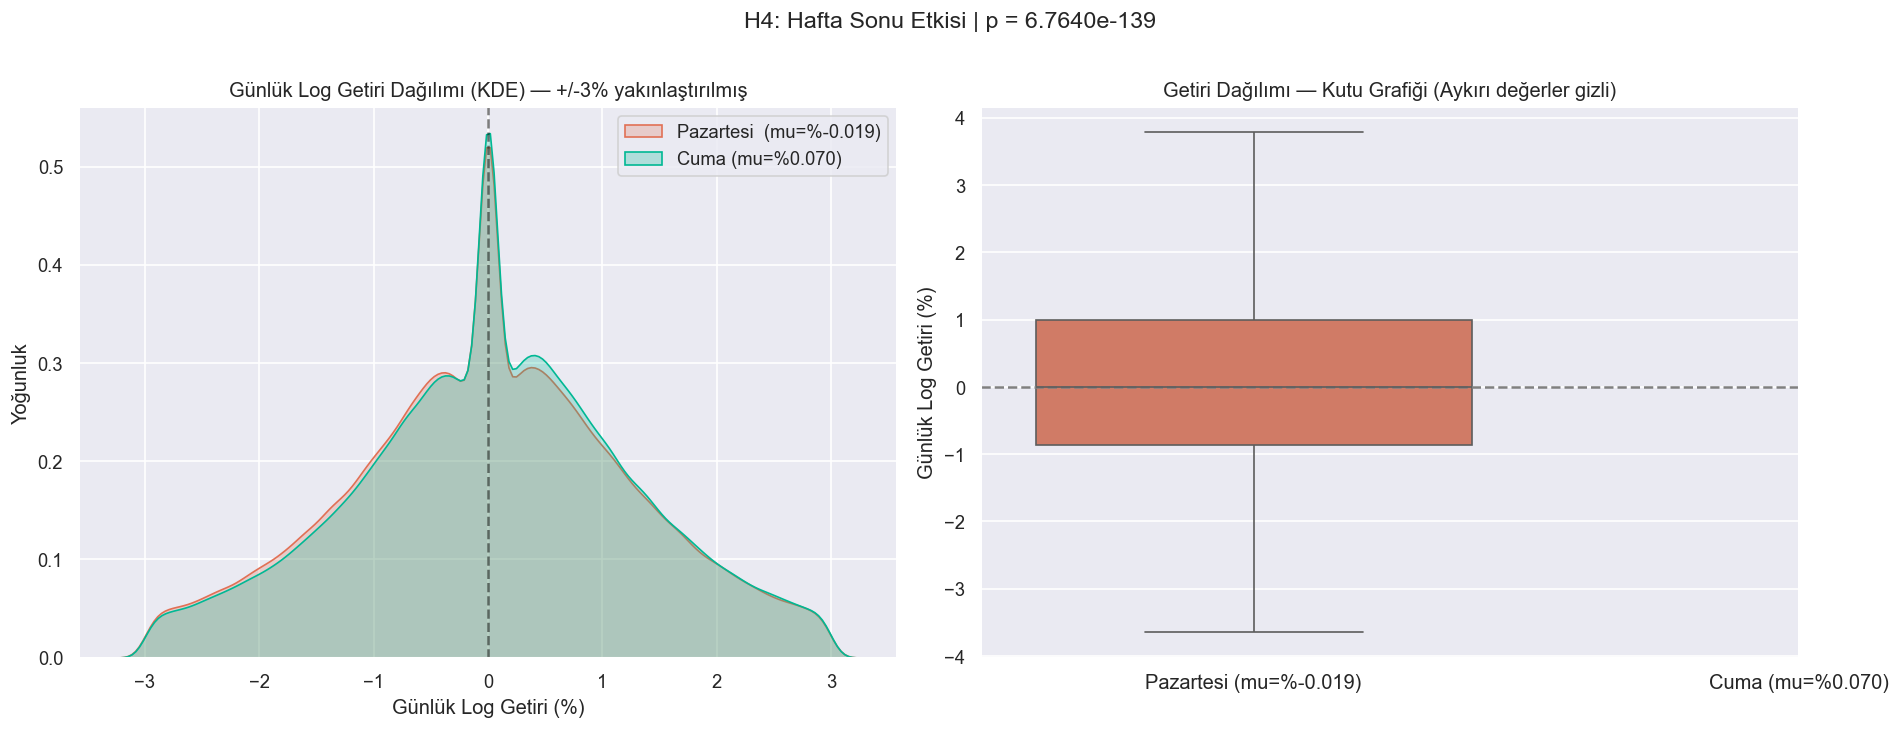

In [3]:
friday = df[df['day_of_week'] == 5]['log_return'].dropna()
monday = df[df['day_of_week'] == 1]['log_return'].dropna()

t_stat, p_value = stats.ttest_ind(friday, monday, alternative='greater', equal_var=False)

mu_fri  = friday.mean()
mu_mon  = monday.mean()
sk_fri  = stats.skew(friday)
sk_mon  = stats.skew(monday)
kurt_fri = stats.kurtosis(friday, fisher=True)
kurt_mon = stats.kurtosis(monday, fisher=True)

h4_result  = "✅ DOĞRULANDI" if p_value < 0.05 else "❌ REDDEDİLDİ"
diff       = mu_fri - mu_mon
tradeable  = "Muhtemelen Hayır" if diff < 0.05 else "Potansiyel olarak — maliyet analizini çalıştırın"
ml_feature = "Evet — haftanın gününü kategorik özellik olarak ekleyin." if p_value < 0.05 else "Hayır — haftanın günü öngörüsel değer katmıyor."
interp     = ("S&P 500 evreni genelinde istatistiksel olarak anlamlı bir Cuma-Pazartesi getiri farkı bulunmaktadır."
              if p_value < 0.05 else
              "Cuma ve Pazartesi getirileri arasında istatistiksel olarak anlamlı bir fark yoktur.")

verdict = f"""
### 5. İstatistiksel Bulgular

| Metrik | Cuma | Pazartesi |
|---|---|---|
| **N** | {len(friday):,} | {len(monday):,} |
| **Ort. Log Getiri** | **%{mu_fri:.4f}** | **%{mu_mon:.4f}** |
| **Çarpıklık (Skewness)** | {sk_fri:.3f} | {sk_mon:.3f} |
| **Aşırı Basıklık (Kurtosis)** | {kurt_fri:.3f} | {kurt_mon:.3f} |

| Test | Değer |
|---|---|
| **T-İstatistiği** | {t_stat:.4f} |
| **p-değeri (tek kuyruklu)** | {p_value:.4e} |
| **H₀ Kararı** | {'Reddedildi (p < 0.05)' if p_value < 0.05 else 'Reddedilmedi (p >= 0.05)'} |

### 6. Ticari Karar (Quant Verdict)

| | |
|---|---|
| **Sonuç** | **{h4_result}** |
| **Ortalama Getiri Farkı** | %{diff:.4f} (Cuma eksi Pazartesi) |
| **Yorum** | {interp} |
| **Maliyetler sonrası ticarete uygun mu?** | **{tradeable}** |
| **ML Özellik Değeri** | {ml_feature} |
"""

display(Markdown(verdict))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
fri_z = friday[(friday > -3) & (friday < 3)]
mon_z = monday[(monday > -3) & (monday < 3)]
sns.kdeplot(mon_z,  fill=True, color="#E17055", label=f"Pazartesi  (mu=%{mu_mon:.3f})",  ax=ax)
sns.kdeplot(fri_z, fill=True, color="#00B894", label=f"Cuma (mu=%{mu_fri:.3f})", ax=ax)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("Günlük Log Getiri Dağılımı (KDE) — +/-3% yakınlaştırılmış", fontsize=12)
ax.set_xlabel("Günlük Log Getiri (%)")
ax.set_ylabel("Yoğunluk")
ax.legend()

ax = axes[1]
sns.boxplot(data=[monday, friday], palette=["#E17055", "#00B894"], showfliers=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Pazartesi (mu=%{mu_mon:.3f})", f"Cuma (mu=%{mu_fri:.3f})"], fontsize=12)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel("Günlük Log Getiri (%)")
ax.set_title("Getiri Dağılımı — Kutu Grafiği (Aykırı değerler gizli)", fontsize=12)

plt.suptitle(f"H4: Hafta Sonu Etkisi | p = {p_value:.4e}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
